<a href="https://colab.research.google.com/github/romrncls/credit-card-fraud-analysis/blob/main/Data_Mining_Rommel_Roncales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 1: Import libraries and set display options

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [3]:
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)

# Step 2: Load the dataset

In [14]:
df = pd.read_csv('/content/bank_marketing_training.csv')
df.shape

(26874, 21)

In [19]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,days_since_previous,previous,previous_outcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,response
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
2,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,217,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
3,25,services,single,high.school,no,yes,no,telephone,may,mon,222,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no
4,29,blue-collar,single,high.school,no,no,yes,telephone,may,mon,137,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no


In [22]:
# add index field
df['index'] = pd.Series(range(0,26874))
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,days_since_previous,previous,previous_outcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,response,index
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no,1
2,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,217,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no,2
3,25,services,single,high.school,no,yes,no,telephone,may,mon,222,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no,3
4,29,blue-collar,single,high.school,no,no,yes,telephone,may,mon,137,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no,4


In [25]:
# changing misleading field values
df['days_since_previous'] = df['days_since_previous'].replace({999: np.nan})
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,days_since_previous,previous,previous_outcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,response,index
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no,1
2,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,217,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no,2
3,25,services,single,high.school,no,yes,no,telephone,may,mon,222,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no,3
4,29,blue-collar,single,high.school,no,no,yes,telephone,may,mon,137,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no,4


<Axes: title={'center': 'Histogram of Days Since Previous'}, ylabel='Frequency'>

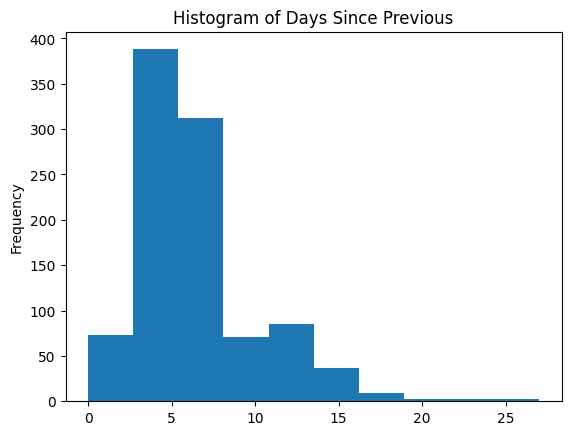

In [26]:
df['days_since_previous'].plot(kind = 'hist', title = 'Histogram of Days Since Previous')

In [36]:
# Re-Expression of Categorical Data as Numeric
df['education_numeric'] = df['education']
dict_edu = {"education_numeric": {"illiterate": 0, "basic.4y": 4,
"basic.6y": 6, "basic.9y": 9, "high.school":12, "professional.course": 12,
"university.degree":16, "unknown": np.nan}}
df.replace(dict_edu, inplace=True)
df.head()

/tmp/ipykernel_2043/3677328975.py:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(dict_edu, inplace=True)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,days_since_previous,previous,previous_outcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,response,index,education_numeric,age_z
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no,0,4.0,1.539625
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no,1,12.0,1.635778
2,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,217,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no,2,NaN,0.097330
3,25,services,single,high.school,no,yes,no,telephone,may,mon,222,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no,3,12.0,-1.441118
4,29,blue-collar,single,high.school,no,no,yes,telephone,may,mon,137,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no,4,12.0,-1.056506


In [38]:
# standardize numeric field as z-score

from scipy import stats

df['age_z'] = stats.zscore(df['age'])
df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,days_since_previous,previous,previous_outcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,response,index,education_numeric,age_z
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no,0,4.0,1.539625
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no,1,12.0,1.635778
2,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,217,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no,2,NaN,0.097330
3,25,services,single,high.school,no,yes,no,telephone,may,mon,222,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no,3,12.0,-1.441118
4,29,blue-collar,single,high.school,no,no,yes,telephone,may,mon,137,1,NaN,0,nonexistent,1.1,93.994,-36.4,4.857,5191,no,4,12.0,-1.056506


In [47]:
df.query('age_z > 3 | age_z < -3')

df_outliers = df.query('age_z > 3 | age_z < -3')

df_sort = df_outliers.sort_values(['age_z'], ascending = False)

# Step 3: Initial inspection and basic data understanding

In [48]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26874 entries, 0 to 26873
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  26874 non-null  int64  
 1   job                  26874 non-null  object 
 2   marital              26874 non-null  object 
 3   education            26874 non-null  object 
 4   default              26874 non-null  object 
 5   housing              26874 non-null  object 
 6   loan                 26874 non-null  object 
 7   contact              26874 non-null  object 
 8   month                26874 non-null  object 
 9   day_of_week          26874 non-null  object 
 10  duration             26874 non-null  int64  
 11  campaign             26874 non-null  int64  
 12  days_since_previous  982 non-null    float64
 13  previous             26874 non-null  int64  
 14  previous_outcome     26874 non-null  object 
 15  emp.var.rate         26874 non-null 

,age,duration,campaign,days_since_previous,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,index,education_numeric,age_z
count,26874.000000,26874.000000,26874.000000,982.000000,26874.000000,26874.000000,26874.000000,26874.000000,26874.000000,26874.000000,26874.000000,25747.000000,2.687400e+04
mean,39.987758,257.741907,2.563035,5.992872,0.171058,0.086552,93.575794,-40.481670,3.627879,5167.103446,13436.500000,11.572688,2.284397e-16
std,10.400285,258.977140,2.748746,3.856360,0.487657,1.569716,0.578933,4.626506,1.731948,72.080534,7757.999903,3.874902,1.000019e+00
min,17.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.000000,0.000000,0.000000,-2.210342e+00
25%,32.000000,103.000000,1.000000,3.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.000000,6718.250000,9.000000,-7.680469e-01
50%,38.000000,180.000000,2.000000,6.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,13436.500000,12.000000,-1.911289e-01
75%,47.000000,319.000000,3.000000,7.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.000000,20154.750000,16.000000,6.742481e-01
max,91.000000,4918.000000,43.000000,27.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.000000,26873.000000,16.000000,4.904980e+00


In [10]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

len(categorical_cols),categorical_cols, len(numerical_cols), numerical_cols

# checking missing values
df.isnull().sum().sort_values(ascending=True)



,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [49]:
# Sample class balance if target column is 'y'
if 'y' in df.columns:
  print(df['y'].value_counts(normalize=True))

# Step 4. Basic Data Cleaning

In [53]:
# Remove exact duplicate rows
df = df.drop_duplicates()

# Trim whitespace in string columns
for c in categorical_cols:
  df[c] = df[c].astype(str).str.strip()

# Optional: standardize category case (example)
for c in categorical_cols:
  df[c] = df[c].str.lower()

# Optional: detect outliers in a numerical feature (e.g., 'balance')
if 'balance' in df.columns:
  q1, q3 = df['balance'].quantile([0.25, 0.75])
  iqr = q3 - q1
  lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
  print(f"Balance IQR bounds: {lower:.2f} to {upper:.2f}")

# Step 5: Define target and features
Goal: Separate the label from predictors (make sure to review the dataset and check what your preferred target is).

In [60]:
# Adjust target name as needed (e.g., 'y' for subscription)
target_col = 'age' # change if different
assert target_col in df.columns, "Update target_col to match your dataset."

X = df.drop(columns=[target_col])
y = df[target_col]
X.head(), y.head()

(           job  marital    education  default housing loan    contact month day_of_week  duration  campaign  \
 0    housemaid  married     basic.4y       no      no   no  telephone   may         mon       261         1   
 1     services  married  high.school  unknown      no   no  telephone   may         mon       149         1   
 2  blue-collar  married      unknown  unknown      no   no  telephone   may         mon       217         1   
 3     services   single  high.school       no     yes   no  telephone   may         mon       222         1   
 4  blue-collar   single  high.school       no      no  yes  telephone   may         mon       137         1   
 
    days_since_previous  previous previous_outcome  emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  \
 0                  NaN         0      nonexistent           1.1          93.994          -36.4      4.857   
 1                  NaN         0      nonexistent           1.1          93.994          -36.4      4.857

# Step 6: Encode categorical variables and impute missing values
Goal: Convert categories to numeric and fill missing values.

In [61]:
# Recompute after any changes
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Pipelines for each data type
numeric_transformer = Pipeline(steps=[
  ('imputer', SimpleImputer(strategy='median')),
  ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
  ('imputer', SimpleImputer(strategy='most_frequent')),
  ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
  transformers=[
    ('num', numeric_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
  ],
  remainder='drop'
)

# Fit and transform
X_processed = preprocessor.fit_transform(X)

# Get feature names after one-hot
cat_feature_names = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_cols)
feature_names = numerical_cols + cat_feature_names.tolist()

X_processed = pd.DataFrame(X_processed, columns=feature_names)
X_processed.head()

,duration,campaign,days_since_previous,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,index,education_numeric,age_z,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_divorced,marital_married,marital_single,marital_unknown,education_basic.4y,education_basic.6y,education_basic.9y,education_high.school,education_illiterate,education_professional.course,education_university.degree,education_unknown,default_no,default_unknown,default_yes,housing_no,housing_unknown,housing_yes,loan_no,loan_unknown,loan_yes,contact_cellular,contact_telephone,month_apr,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,previous_outcome_failure,previous_outcome_nonexistent,previous_outcome_success,response_no,response_yes
0,0.012581,-0.568646,0.000354,-0.350781,0.645637,0.722388,0.882252,0.709689,0.331532,-1.731986,-2.000859,1.539625,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,-0.419898,-0.568646,0.000354,-0.350781,0.645637,0.722388,0.882252,0.709689,0.331532,-1.731857,0.107914,1.635778,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,-0.157321,-0.568646,0.000354,-0.350781,0.645637,0.722388,0.882252,0.709689,0.331532,-1.731729,0.107914,0.097330,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,-0.138014,-0.568646,0.000354,-0.350781,0.645637,0.722388,0.882252,0.709689,0.331532,-1.731600,0.107914,-1.441118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,-0.466235,-0.568646,0.000354,-0.350781,0.645637,0.722388,0.882252,0.709689,0.331532,-1.731471,0.107914,-1.056506,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


# Step 7: Train-test split
Goal: Create hold-out sets for modeling.

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
  X_processed, y, test_size=0.2, random_state=42, stratify=y

  if y.nunique() <= 20

  else None
)

X_train.shape, X_test.shape

((21499, 67), (5375, 67))

# Step 8: Optional Exploratory Checks

Train class distribution:
age
31    0.046932
32    0.044839
35    0.043956
33    0.043490
34    0.042188
        ...   
83    0.000279
86    0.000279
17    0.000186
84    0.000186
91    0.000047
Name: proportion, Length: 72, dtype: float64

Test class distribution:
age
36    0.050791
33    0.045581
34    0.045395
31    0.045395
35    0.043721
        ...   
85    0.000186
86    0.000186
79    0.000186
91    0.000186
77    0.000186
Name: proportion, Length: 71, dtype: float64


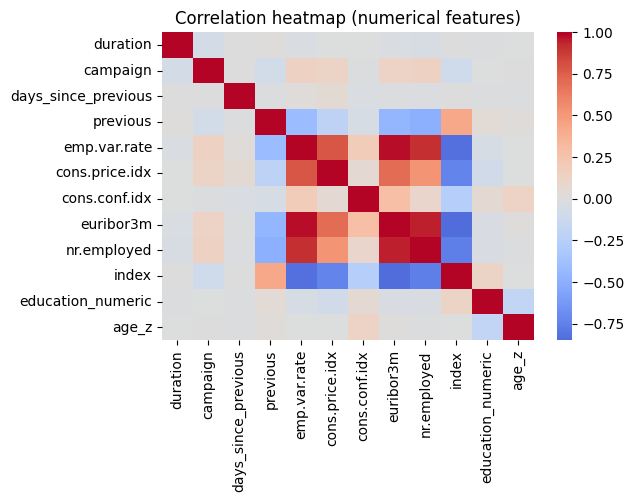

In [65]:
# Class balance in train/test
print("Train class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

# Quick correlation heatmap for numerics (after scaling, most meaningful for original numerics)
if len(numerical_cols) > 1:
  corr = pd.DataFrame(preprocessor.named_transformers_['num']['imputer'].transform(X[numerical_cols]),
            columns=numerical_cols).corr()
  plt.figure(figsize=(6,4))
  sns.heatmap(corr, cmap='coolwarm', center=0)
  plt.title('Correlation heatmap (numerical features)')
  plt.show()